# Product Analytics Case Study - Retailrocket Dataset 

## 1. Introduction

This case study is aimed to provide a product analysis (in particular funnel and retention) of Retailrocket dataset.

Retailrocket is public dataset from Kaggle 

URL: https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset

## 2. Data overview

In [1]:
import pandas as pd

df = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-egor-sakulin-wkf7957/Product_project/Data/events.csv')
df.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [3]:
print(df.info())
print(df['event'].value_counts())
print(df['visitorid'].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB
None
view           2664312
addtocart        69332
transaction      22457
Name: event, dtype: int64
1407580


Dataset contains 1407580 users and events: view - 2664312, addtocart - 69332, transaction - 22457

## 3. Funnel analysis

In [4]:
views = df[df['event'] == 'view']['visitorid'].nunique()
cart = df[df['event'] == 'addtocart']['visitorid'].nunique()
purchase = df[df['event'] == 'transaction']['visitorid'].nunique()

views, cart, purchase

(1404179, 37722, 11719)

In [10]:
cart_rate = cart / views 
cart_rate_pct = round(cart_rate * 100, 2)

purchase_rate = purchase / cart 
purchase_rate_pct = round(purchase_rate * 100, 2)

Main_rate = purchase / views
overall_conversion_pct = round(Main_rate * 100, 2)

cart_rate_pct, purchase_rate_pct, overall_conversion_pct

(2.69, 31.07, 0.83)

User progression through the key stages of the purchase funnel:

- View: 1404179 users
- Add to Cart: 37722 users
- Purchase: 11719 users

Conversion rates:
- View → Cart: 2.69%
- Cart → Purchase: 31.07%
- View → Purchase (overall): 0.83%

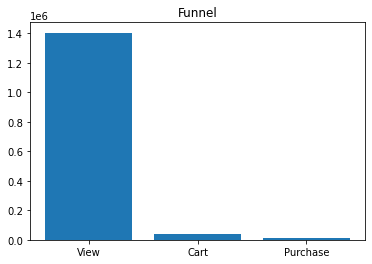

In [11]:
import matplotlib.pyplot as plt

stages = ['View', 'Cart', 'Purchase']
values = [views, cart, purchase]

plt.bar(stages, values)
plt.title('Funnel')
plt.show()

### Key Insights

- The largest drop-off occurs between View and Add to Cart
- Only 0.83% of users who view products proceed to purchase
- This suggests potential friction in product discovery, user engagement, or product page effectiveness rather than in the checkout process

### Business Interpretation


This indicates that the primary bottleneck is not conversion, but user engagement and intent generation.

The low overall conversion rate indicates that users are not successfully progressing through the early stages of the funnel.

While the Cart → Purchase conversion rate is relatively strong (31.07%), the very low View → Cart conversion (2.69%) highlights that most users drop off before showing purchase intent.

Possible reasons:
- Low product attractiveness or weak value proposition
- Poor product page experience (images, descriptions, UX)
- Ineffective recommendation or discovery system


## 4. Retention analysis

In [19]:
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
df['date'] = df['datetime'].dt.date

cohort = df.groupby('visitorid')['date'].min()
df = df.join(cohort, on='visitorid', rsuffix='_cohort')

df['days_since_first'] = (df['date'] - df['date_cohort']).dt.days

cohort_data = df.groupby(['date_cohort', 'days_since_first'])['visitorid'].nunique().reset_index()

Retention

In [23]:
retention = cohort_data.pivot(index='date_cohort', columns='days_since_first', values='visitorid')
retention = retention.div(retention[0], axis=0)
retention = retention.iloc[:, :30]

Retention Heatmap

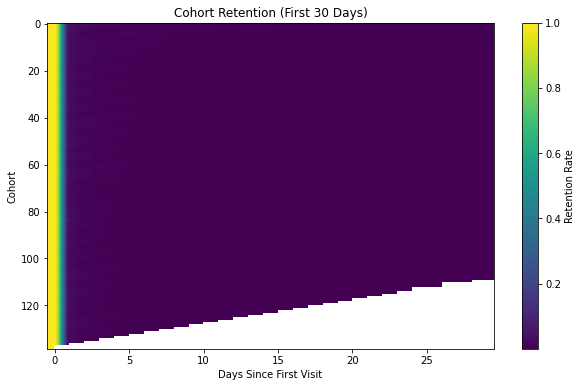

In [24]:
plt.figure(figsize=(10,6))
plt.imshow(retention, aspect='auto')
plt.colorbar(label='Retention Rate')
plt.title('Cohort Retention (First 30 Days)')
plt.xlabel('Days Since First Visit')
plt.ylabel('Cohort')
plt.show()

In [26]:
d1 = retention[1].mean()
d7 = retention[7].mean()

round(d1*100, 2), round(d7*100, 2)

(2.74, 0.56)

Retention d1, d7
- Day 1 retention: 2.74%
- Day 7 retention: 0.56%

### Key Insights

- Retention drops sharply after Day 1
- Very few users return after the first interaction

### Business Interpretation

Low retention indicates weak user engagement and low product stickiness.

## 5. Insights & Recommendations

### Combined Insights

Low conversion (0.83%) combined with low retention (D1: 2.74%, D7: 0.56%) indicates that users neither convert nor return.

This suggests that the core issue is not in the checkout process, but in overall product value and user engagement.
